# Model Comparison with Different Numbers of Parameters

This tutorial shows how to compare candidate simulation models that have **different numbers of physical parameters** with the `compass` package.

In the [Gaussian models tutorial](Gaussian_models.ipynb) all competing hypotheses had the same number of parameters, so ranking them by their likelihoods was already fair. In practice, however, candidate models often differ in complexity: one theory might explain your data with 2 parameters, a competing one with 3 or 5. `compass` now handles this case correctly:

- The complexity penalty uses each model's **physical parameter count** ($k$ = the dimension of $\theta$, read automatically from the posterior samples) — *not* the neural-network weight count.
- Models are ranked by the **corrected Akaike Information Criterion (AICc)** by default and converted to relative model weights, $w_i = \mathrm{softmax}(-\tfrac{1}{2}\,\mathrm{AICc}_i)$.
- The **Bayesian Information Criterion (BIC)** is computed alongside AICc, using the same likelihood term but a $k\ln n$ complexity penalty.
- A **small-sample guard** falls back to the plain AIC whenever $n_{\mathrm{obs}} - k - 1 \le 0$, where the AICc correction term would be undefined.

## Why not just compare likelihoods?

A model with more free parameters can *always* fit the data at least as well as a simpler nested model — the extra parameters give it more freedom, even if they describe nothing real. Ranking models by raw likelihood therefore systematically favors the more complex model and is **unfair to simpler models**.

The AICc restores fairness by charging each model for its complexity:

$$\mathrm{AICc} = \underbrace{2k - 2\ln \hat{L}}_{\text{plain AIC}} + \underbrace{\frac{2k^2 + 2k}{n - k - 1}}_{\text{small-sample correction}}$$

where $k$ is the number of physical parameters, $\hat{L}$ the maximized likelihood, and $n$ the number of observations. **Lower AICc is better.** The extra parameters of an overly complex model must *earn their keep* by improving the fit by more than the penalty — otherwise the simpler model wins. The Akaike weights $w_i = \mathrm{softmax}(-\tfrac{1}{2}\,\mathrm{AICc}_i)$ turn the criterion into easy-to-read relative model probabilities (higher = better), so you never have to worry about the sign convention yourself.

BIC uses the same unpenalized fit term, $-2\ln\hat{L}$, but replaces AICc's penalty with one that grows with the sample size:

$$\mathrm{BIC} = k\ln(n) - 2\ln \hat{L}$$

**Lower BIC is better.** Compared with AIC/AICc, BIC penalizes extra parameters more strongly once $\ln(n) > 2$ (roughly $n \ge 8$), so it is more conservative about adding parameters. In `compass`, `criterion="bic"` uses the same softmax weighting idea, $w_i = \mathrm{softmax}(-\tfrac{1}{2}\,\mathrm{BIC}_i)$.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from autocvd import autocvd

from compass import ScoreBasedInferenceModel as SBIm
from compass import ModelTransfuser as MTf

torch.manual_seed(0)
np.random.seed(0)

# Reserve one free GPU and keep CPU helper usage to one thread.
autocvd(num_gpus=1, interval=1)
device = "cuda"
torch.set_num_threads(1)


## Toy problem: a line vs. a line with an unnecessary extra term

We observe a signal $y$ on a small grid of 5 points $t \in [0, 1]$. The **true** generative process is a straight line with 2 parameters (offset $a$ and slope $b$):

$$y(t) = a + b\,t + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.1^2)$$

We pit two candidate models against each other:

- **Model A (2 parameters)** — offset + slope, exactly the true process:
$$a, b \sim \mathcal{N}(0,1), \qquad y(t) = a + b\,t + \varepsilon$$

- **Model B (3 parameters)** — the same line, plus a third parameter $c$ ("curvature") that is drawn from its prior but **never enters the data**:
$$a, b, c \sim \mathcal{N}(0,1), \qquad y(t) = a + b\,t + \varepsilon$$

Model B can fit the data exactly as well as Model A — the spurious parameter $c$ neither helps nor hurts the fit. A raw likelihood comparison could not tell them apart. AICc and BIC, however, charge Model B for its unused third parameter, so the *simpler true model should win*.

In [3]:
# Observation grid: 5 points in [0, 1]
t_grid = torch.linspace(0, 1, 5)
NOISE = 0.1

# Model A: 2 parameters (offset a, slope b)
def gen_data_A(n):
    a = torch.randn(n)
    b = torch.randn(n)
    theta = torch.stack([a, b], dim=1)                       # (n, 2)
    y = a[:, None] + b[:, None] * t_grid[None, :] + NOISE * torch.randn(n, len(t_grid))
    return theta, y

# Model B: 3 parameters (offset a, slope b, spurious curvature c)
# c is part of the model's parameter space but does NOT influence y.
def gen_data_B(n):
    a = torch.randn(n)
    b = torch.randn(n)
    c = torch.randn(n)                                       # unused!
    theta = torch.stack([a, b, c], dim=1)                    # (n, 3)
    y = a[:, None] + b[:, None] * t_grid[None, :] + NOISE * torch.randn(n, len(t_grid))
    return theta, y

In [4]:
# Training and validation data for both candidate models
theta_A, x_A = gen_data_A(10_000)
val_theta_A, val_x_A = gen_data_A(1_000)

theta_B, x_B = gen_data_B(10_000)
val_theta_B, val_x_B = gen_data_B(1_000)

print(f"Model A: theta {tuple(theta_A.shape)}  ->  {theta_A.shape[1]} physical parameters")
print(f"Model B: theta {tuple(theta_B.shape)}  ->  {theta_B.shape[1]} physical parameters")
print(f"Both models observe y on {x_A.shape[1]} grid points")

Model A: theta (10000, 2)  ->  2 physical parameters
Model B: theta (10000, 3)  ->  3 physical parameters
Both models observe y on 5 grid points


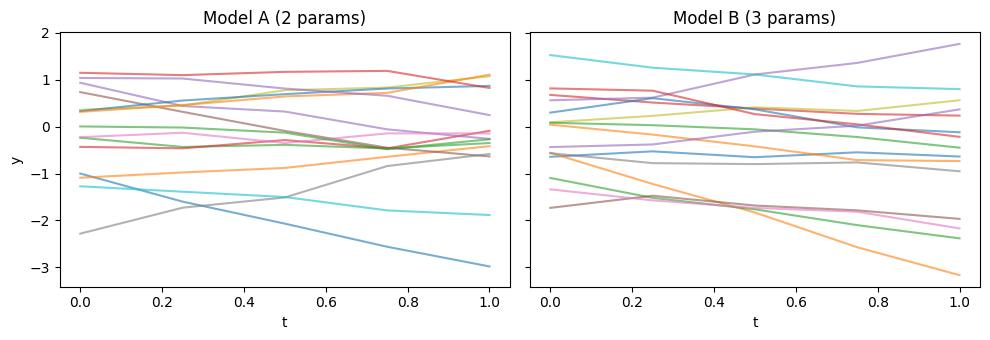

In [5]:
# A quick look at a few simulated curves from each model.
# The two panels are indistinguishable -- exactly the point of this tutorial.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, (name, y) in zip(axes, [("Model A (2 params)", x_A), ("Model B (3 params)", x_B)]):
    for i in range(15):
        ax.plot(t_grid, y[i], alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel("t")
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

## Training the surrogate models

We train one `ScoreBasedInferenceModel` per candidate on a single GPU reserved by `autocvd`. Note that the two models have **different `nodes_size`**: Model A works on a $(2 + 5)$-dimensional joint space, Model B on $(3 + 5)$. This is exactly the situation the parameter-count-aware comparison was built for.

(We train the two models directly here so we can pass different data shapes to each; you can equally use `mtf.add_data(...)` + `mtf.init_models(...)` + `mtf.train_models(...)` as in the Gaussian tutorial — the comparison logic is the same.)

In [6]:
path = "data/variable_params"

sbim_A = SBIm(nodes_size=theta_A.shape[1] + x_A.shape[1],   # 2 + 5
              sde_type="vesde", sigma=3,
              hidden_size=16, depth=2, num_heads=2, mlp_ratio=2)

sbim_B = SBIm(nodes_size=theta_B.shape[1] + x_B.shape[1],   # 3 + 5
              sde_type="vesde", sigma=3,
              hidden_size=16, depth=2, num_heads=2, mlp_ratio=2)

In [7]:
%%time
sbim_A.train(theta=theta_A, x=x_A, theta_val=val_theta_A, x_val=val_x_A,
             batch_size=256, max_epochs=40, lr=1e-3, device=device,
             verbose=False, path=path, name="Model A", early_stopping_patience=10)
print("Model A trained")

Model A trained
CPU times: user 21.7 s, sys: 1.18 s, total: 22.8 s
Wall time: 24.8 s


In [8]:
%%time
sbim_B.train(theta=theta_B, x=x_B, theta_val=val_theta_B, x_val=val_x_B,
             batch_size=256, max_epochs=40, lr=1e-3, device=device,
             verbose=False, path=path, name="Model B", early_stopping_patience=10)
print("Model B trained")

Model B trained
CPU times: user 25.8 s, sys: 200 ms, total: 26 s
Wall time: 26.4 s


## Running the comparison

We register both trained models with a `ModelTransfuser` and generate 25 test observations **from the true 2-parameter model**. `compare()` then, for each model:

1. infers the MAP parameters for each observation (posterior sampling),
2. models the likelihood around the MAP estimate,
3. evaluates the log-likelihood of each observation,
4. computes the no-penalty fit term plus AICc and BIC — with $k$ read automatically from each model's posterior shape — and converts the selected criterion into relative model weights.

In [9]:
mtf = MTf(path=path)
mtf.add_model("Model A (2 params)", sbim_A)
mtf.add_model("Model B (3 params)", sbim_B)

Model Model A (2 params) added to transfuser.
Model Model B (3 params) added to transfuser.


In [10]:
# 25 observations generated from the TRUE 2-parameter process
_, x_test = gen_data_A(25)
print(f"Test observations: {tuple(x_test.shape)}")

Test observations: (25, 5)


In [11]:
%%time
mtf.compare(x=x_test, device=device, num_samples=500, timesteps=50, verbose=False)

Comparing models:   0%|                                 | 0/2 [00:00<?, ?model/s]

Comparing models: 100%|█████████████████████████| 2/2 [00:11<00:00,  5.91s/model]

Probabilities of the models after 25 observations:
Model A (2 params): 100.00 %
Model B (3 params):   0.00 %

Model Model A (2 params) fits the data best with a relative support of 100.0% among the considered models.
CPU times: user 11.5 s, sys: 121 ms, total: 11.7 s
Wall time: 11.8 s


## Inspecting the results

All results live in `mtf.stats`, keyed by model name. The entries most relevant here:

- `param_count` — the physical parameter count $k$ used in the AICc/BIC penalties (read from the posterior sample shape, so it is always the $\theta$ dimension of that model).
- `neg2_log_likelihood` — the unpenalized fit term, $-2\sum_i \log L_i$ (lower = better, no complexity penalty).
- `AICc` — the summed corrected Akaike information criterion over all observations (lower = better).
- `BIC` — the summed Bayesian information criterion over all observations (lower = better).
- `AIC` — compatibility alias for the criterion selected by `compare()` (`AICc` by default, `BIC` when `criterion="bic"`).
- `model_prob` — the relative model probability from the selected criterion (higher = better).
- `log_probs` / `obs_probs` — per-observation log-likelihoods and model probabilities.


In [12]:
# Relative weights for each criterion, normalized across the supplied models.
model_names = list(mtf.stats)
bic_values = torch.stack([mtf.stats[name]['BIC'] for name in model_names])
no_penalty_values = torch.stack([mtf.stats[name]['neg2_log_likelihood'] for name in model_names])
bic_probs = torch.softmax(-0.5 * (bic_values - bic_values.min()), dim=0)
no_penalty_probs = torch.softmax(-0.5 * (no_penalty_values - no_penalty_values.min()), dim=0)

for i, name in enumerate(model_names):
    stats = mtf.stats[name]
    print(f"{name}")
    print(f"  param_count (k) : {stats['param_count']}")
    print(f"  sum log L       : {stats['log_probs'].sum().item():8.2f}")
    print(f"  -2 log L        : {stats['neg2_log_likelihood'].item():8.2f}  (no penalty)")
    print(f"  AICc            : {stats['AICc'].item():8.2f}")
    print(f"  BIC             : {stats['BIC'].item():8.2f}")
    print(f"  model_prob      : {100 * stats['model_prob']:8.2f} %  (selected criterion)")
    print(f"  BIC prob        : {100 * bic_probs[i].item():8.2f} %")
    print(f"  no-penalty prob : {100 * no_penalty_probs[i].item():8.2f} %")
    print()


Model A (2 params)
  param_count (k) : 2
  sum log L       :    43.52
  -2 log L        :   -87.04  (no penalty)
  AICc            :    26.60
  BIC             :    73.91
  model_prob      :   100.00 %  (selected criterion)
  BIC prob        :   100.00 %
  no-penalty prob :    97.54 %

Model B (3 params)
  param_count (k) : 3
  sum log L       :    39.84
  -2 log L        :   -79.68  (no penalty)
  AICc            :    98.90
  BIC             :   161.74
  model_prob      :     0.00 %  (selected criterion)
  BIC prob        :     0.00 %
  no-penalty prob :     2.46 %



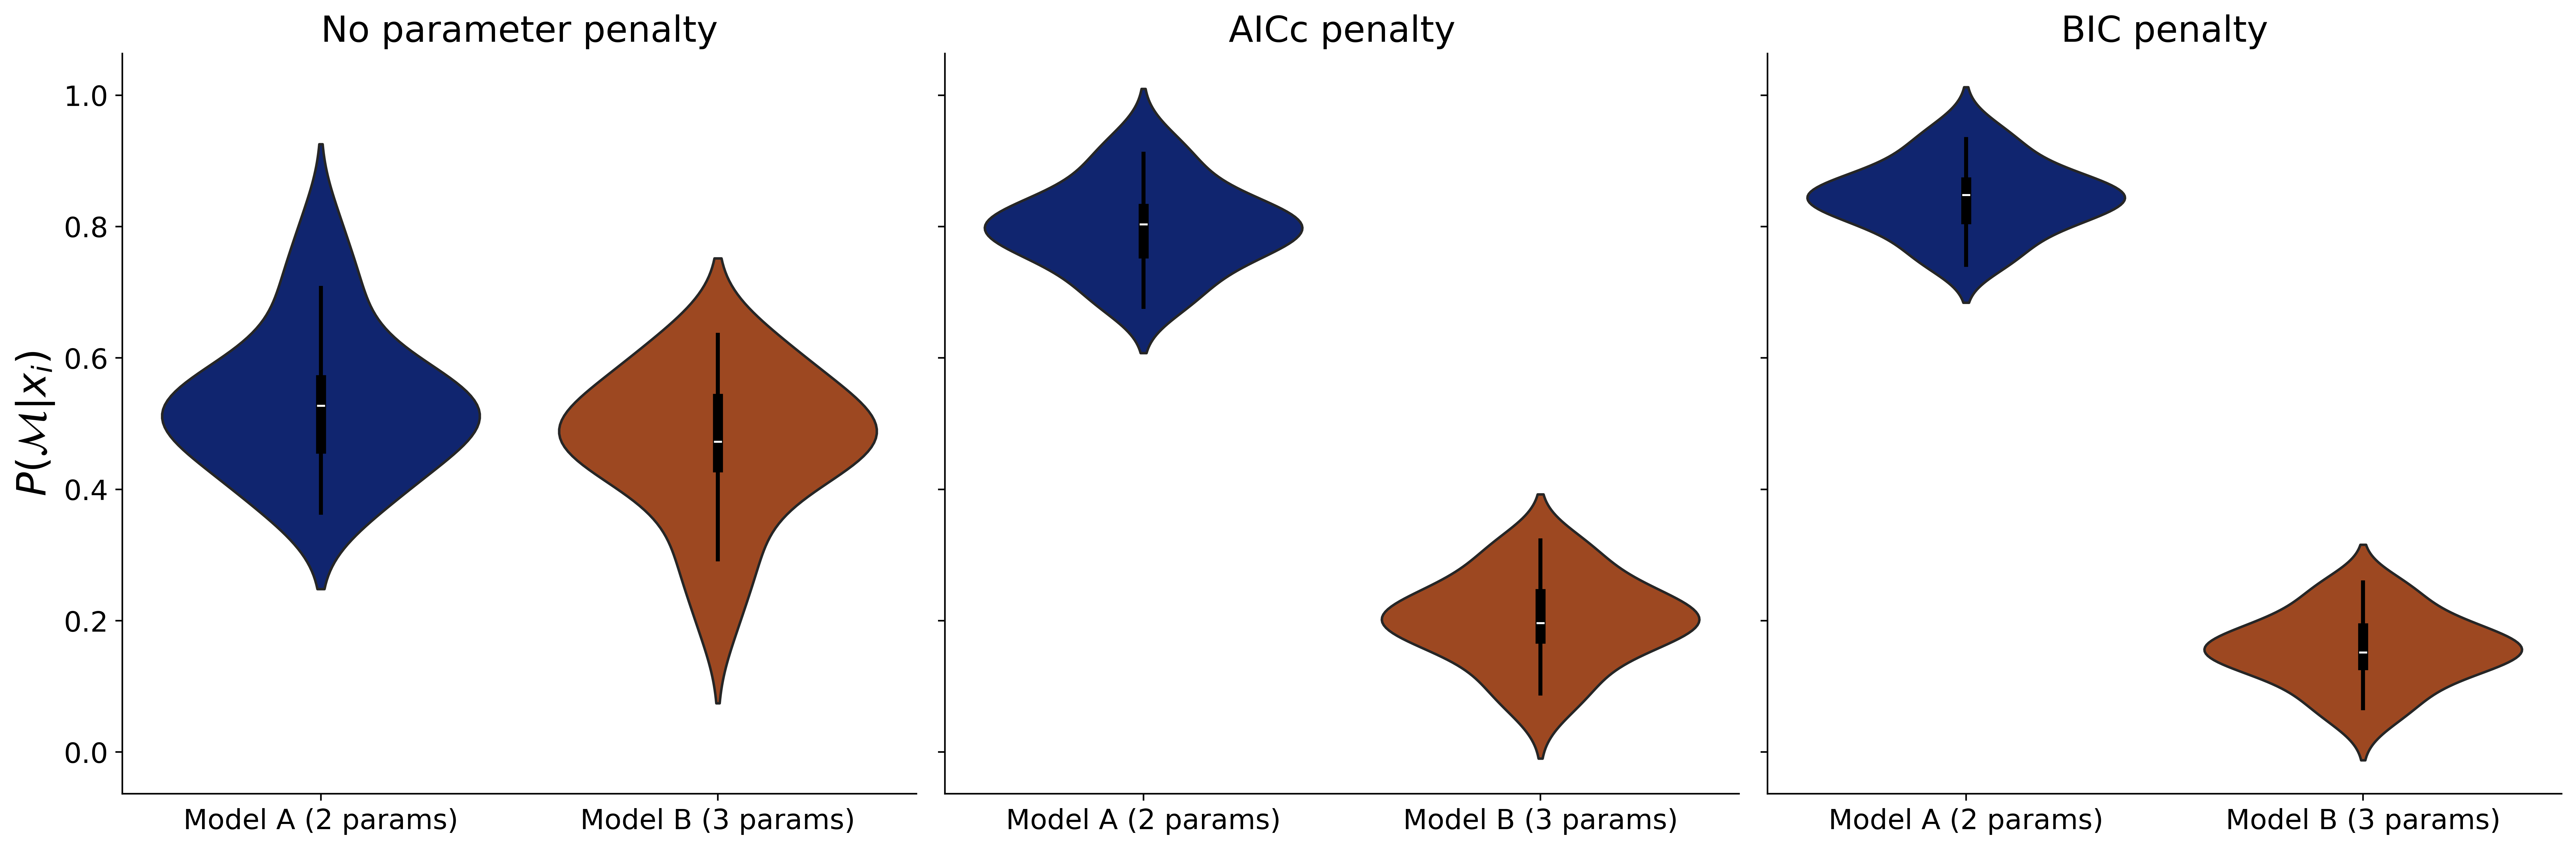

[compass] Warning: AICc small-sample correction is undefined (n_obs - k - 1 <= 0); falling back to plain AIC (2k - 2*logL) for the affected terms.


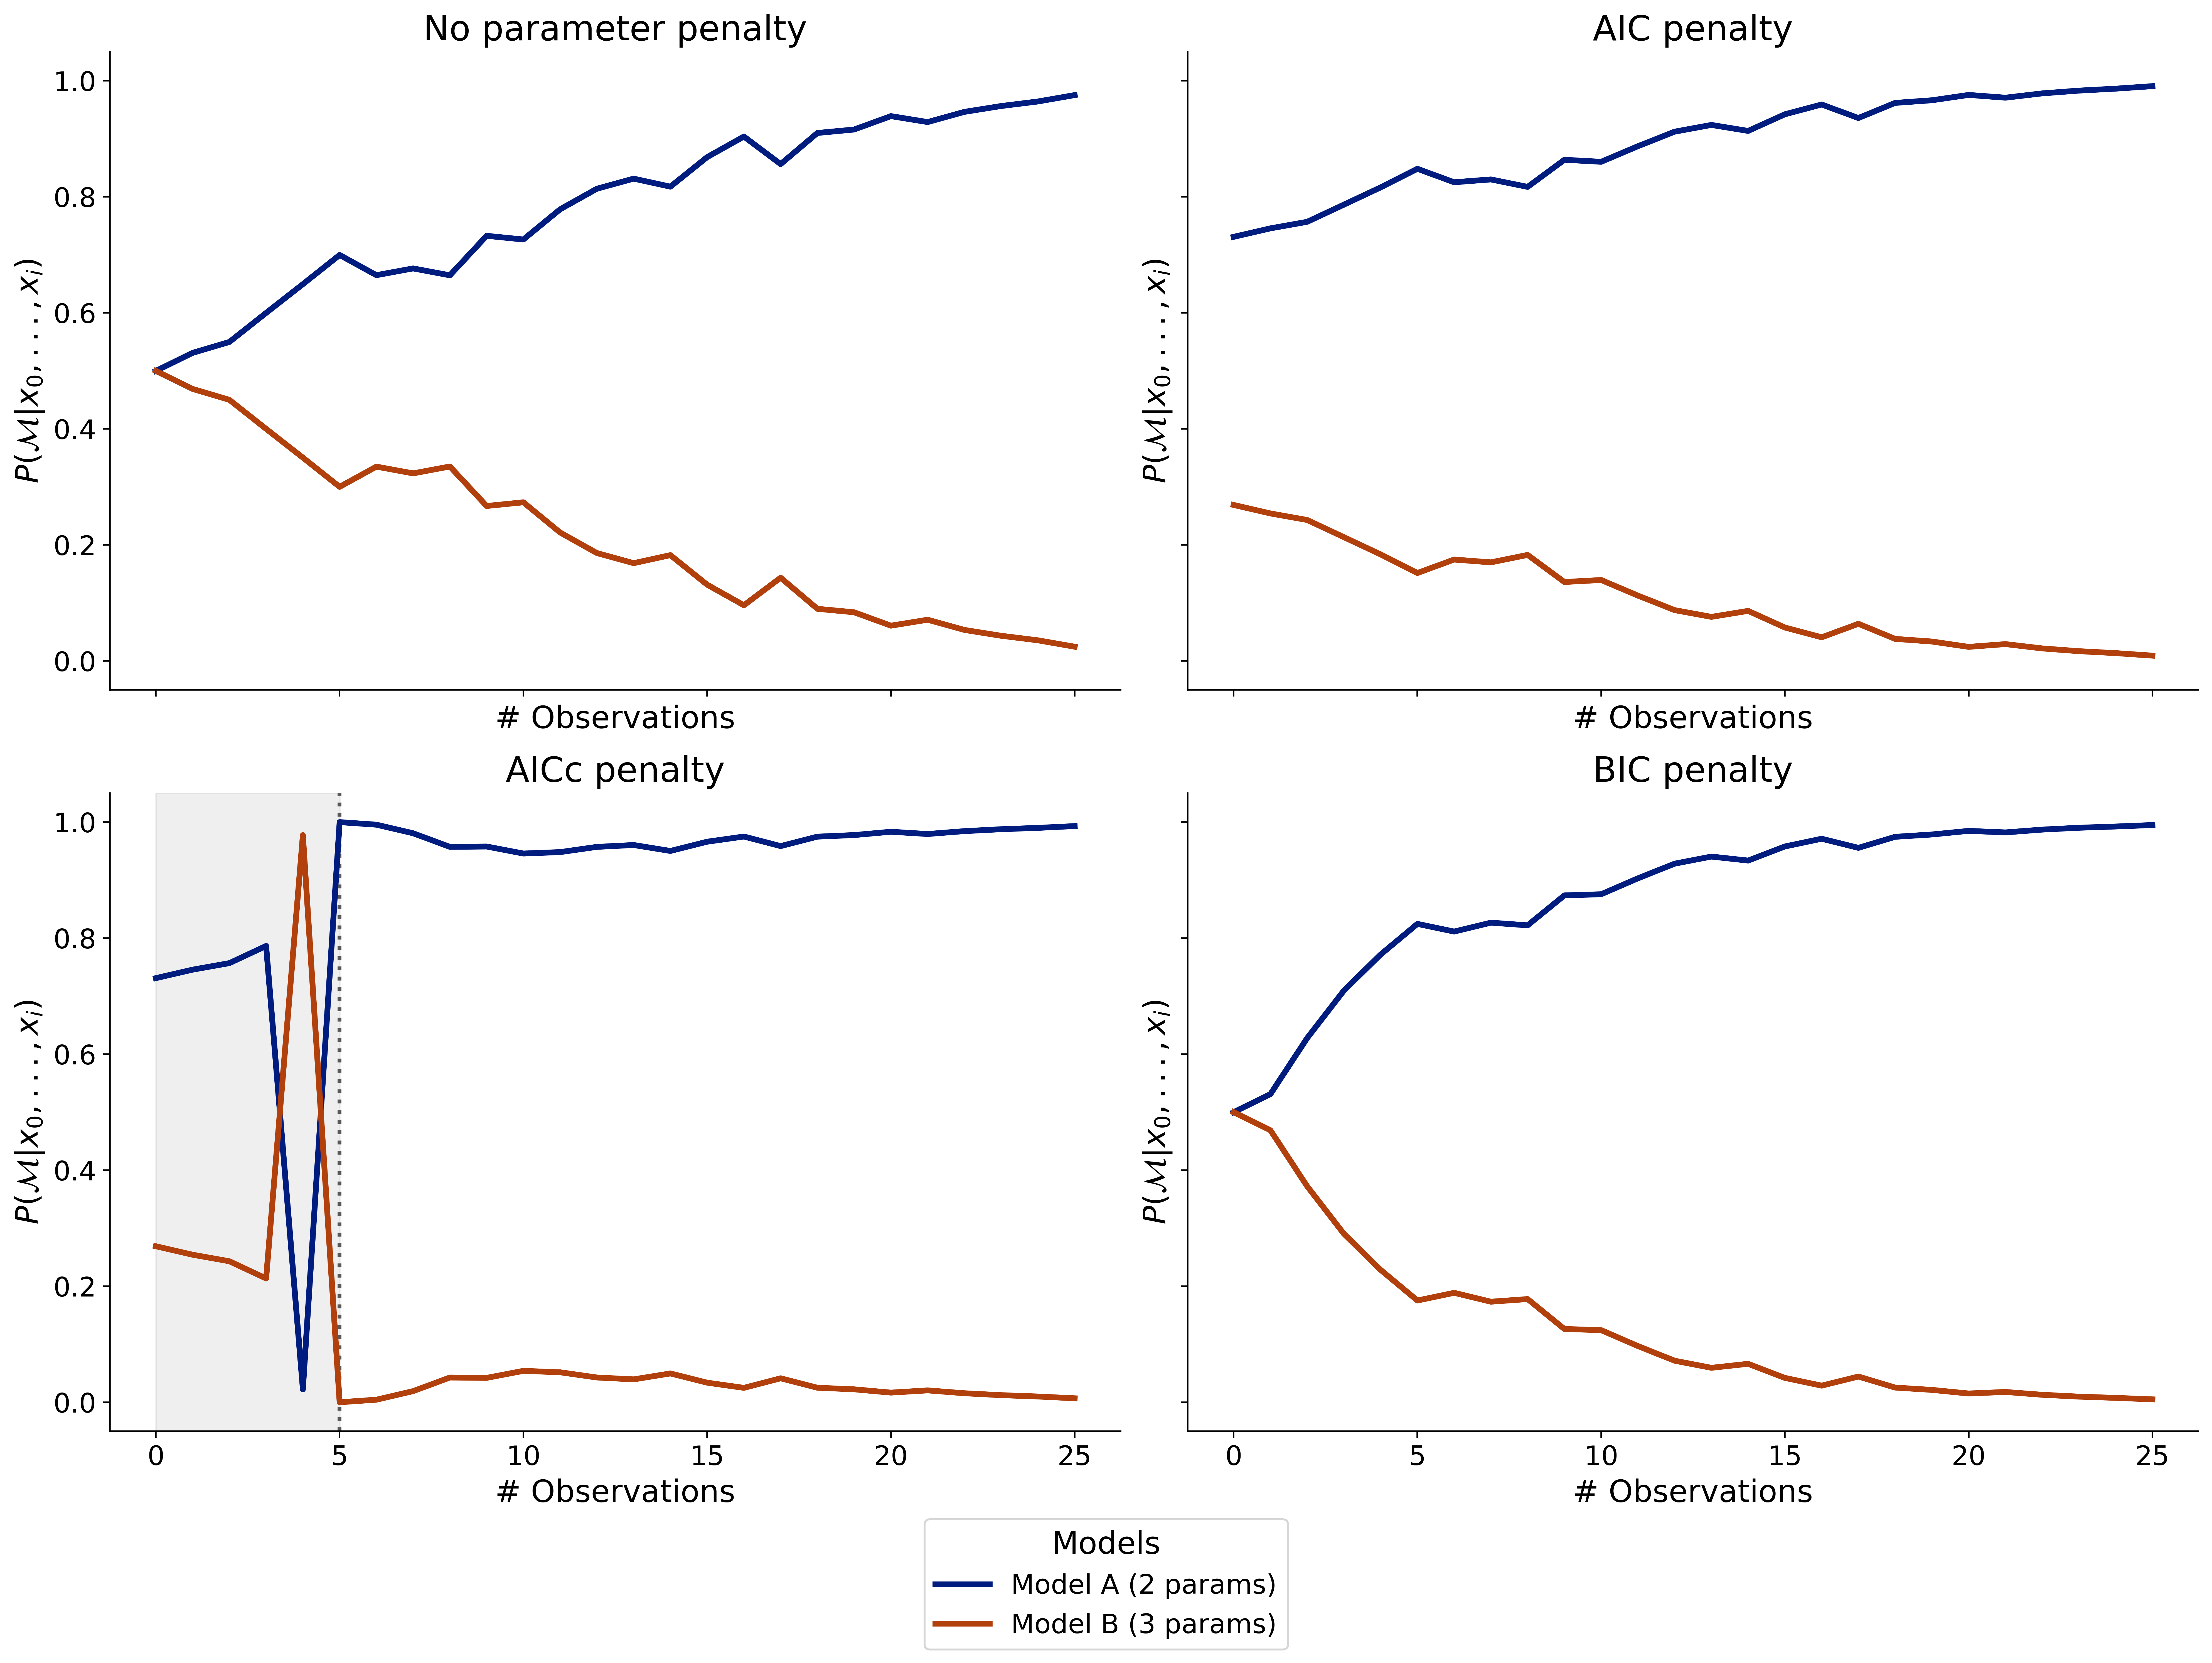

In [13]:
mtf.plot_comparison(path=path)

### Interpretation

Both models fit the data essentially equally well — their summed log-likelihoods are very close, because Model B's third parameter does nothing. But the information-criterion penalties are what separate them: Model B pays for **three** parameters while Model A pays for only **two**, so Model A ends up with the lower AICc/BIC.

This is exactly the behavior you want: **the simpler true model wins even though the richer model fits equally well.** In the violin plot you can see the per-observation probabilities already lean toward Model A, and the cumulative plot shows the preference sharpening as more observations are accumulated — the constant per-observation criterion advantage compounds.

If instead the extra parameter *had* been needed to explain the data, Model B's likelihood advantage would have outgrown its penalty and it would have won. AICc and BIC do not punish complexity by itself; they punish complexity that does not buy enough fit.

*Note:* you may spot the `[compass]` small-sample notice above the cumulative plot. That plot re-evaluates the AICc on random subsets of your observations, including very small ones (1-3 observations), where the correction term is undefined — the guard quietly switches those subsets to the plain AIC. BIC has no AICc-style small-sample correction, but it still depends on using comparable data across models.

## The small-sample guard

The AICc correction term $\frac{2k^2 + 2k}{n - k - 1}$ blows up (or becomes negative and meaningless) when the number of observations is too small: for $n - k - 1 \le 0$ it is simply undefined. With only 3 observations, Model B ($k=3$) hits $3 - 3 - 1 = -1$ and Model A ($k=2$) hits $3 - 2 - 1 = 0$.

Instead of producing garbage, `compass` detects this, **prints a warning once**, and falls back to the plain AIC ($2k - 2\ln\hat{L}$) for the affected terms. Watch for the warning line in the output below.

In [14]:
_, x_tiny = gen_data_A(3)   # only 3 observations
mtf.compare(x=x_tiny, device=device, num_samples=500, timesteps=50, verbose=False)

Comparing models:  50%|████████████▌            | 1/2 [00:04<00:04,  4.93s/model]

[compass] Warning: AICc small-sample correction is undefined (n_obs - k - 1 <= 0); falling back to plain AIC (2k - 2*logL) for the affected terms.


Comparing models: 100%|█████████████████████████| 2/2 [00:09<00:00,  4.99s/model]

Probabilities of the models after 3 observations:
Model A (2 params):  94.95 %
Model B (3 params):   5.05 %

Model Model A (2 params) fits the data best with a relative support of 95.0% among the considered models.


The comparison still completes and the ranking is still usable — but be careful: with so few observations the plain AIC under-penalizes complexity, and the model probabilities are noisy anyway. If you see this warning, the honest fix is to collect (or simulate) more observations, not to trust the numbers harder.

## Practical tips

- **Same data for all models.** AICc and BIC values are only comparable when every model is evaluated on the *identical* set of observations. Never compare information criteria computed on different data sets.
- **$k$ is automatic.** The parameter count is read from each model's posterior sample shape (the $\theta$ dimension), so models with different `nodes_size` can be mixed freely in one `ModelTransfuser` — you don't set $k$ anywhere. It is stored per model in `mtf.stats[name]["param_count"]` so you can verify what was used.
- **Ranking direction.** Lower AICc/BIC = better model; the model weights (`model_prob`, higher = better) encode this via $\mathrm{softmax}(-\tfrac{1}{2}\,\mathrm{IC})$, where `IC` is the selected criterion.
- **Criterion choice.** Use the default AICc when you want a predictive, small-sample-aware comparison; use `criterion="bic"` when you want a stronger penalty for extra parameters.
- **Relative, not absolute.** Model weights are relative support *among the models you supplied*. A 99% weight does not mean the winner is a good model — only that it is the best of the candidates you considered.
- **Small samples.** If you see the small-sample warning ($n_{\mathrm{obs}} - k - 1 \le 0$), the AICc correction was replaced by the plain AIC for the affected models; prefer adding observations over interpreting borderline probabilities.